In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded")

Libraries Loaded


In [2]:
df = pd.read_csv(r'C:\Users\tloun\Desktop\data science project\Customer-Churn-Records.csv')

print(df.shape)
df.head()

(10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [4]:
print(df['Exited'].value_counts())
print()
print('Churn rate:', df['Exited'].mean().round(3))

Exited
0    7962
1    2038
Name: count, dtype: int64

Churn rate: 0.204


In [5]:
#checking for duplicates and basic statistics
print('Duplicates:', df.duplicated().sum())
df.describe()

Duplicates: 0


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


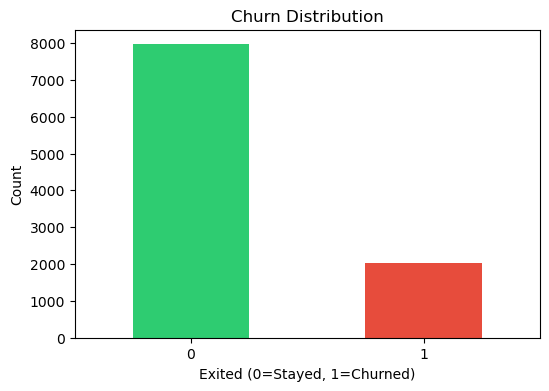

In [6]:
plt.figure(figsize=(6,4))
df['Exited'].value_counts().plot(kind='bar', color=['#2ECC71', '#E74C3C'])
plt.title('Churn Distribution')
plt.xlabel('Exited (0=Stayed, 1=Churned)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

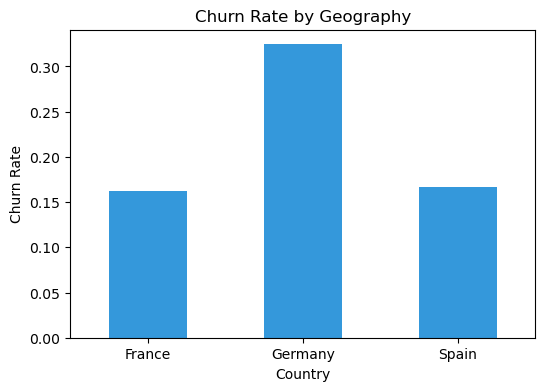

In [7]:
#churn rate by geography:
plt.figure(figsize=(6,4))
df.groupby('Geography')['Exited'].mean().plot(kind='bar', color='#3498DB')
plt.title('Churn Rate by Geography')
plt.xlabel('Country')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

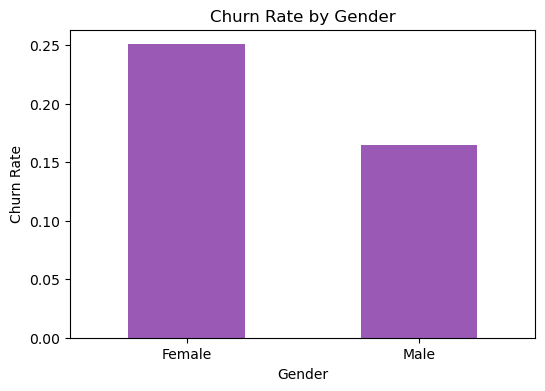

In [8]:
#Churn by Gender
plt.figure(figsize=(6,4))
df.groupby('Gender')['Exited'].mean().plot(kind='bar', color='#9B59B6')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

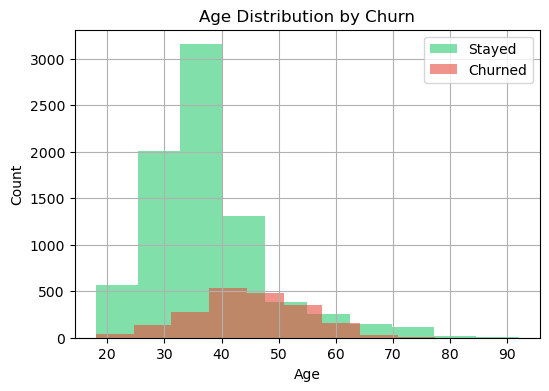

In [9]:
#churn by age distribution
plt.figure(figsize=(6,4))
df[df['Exited']==0]['Age'].hist(alpha=0.6, label='Stayed', color='#2ECC71')
df[df['Exited']==1]['Age'].hist(alpha=0.6, label='Churned', color='#E74C3C')
plt.title('Age Distribution by Churn')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

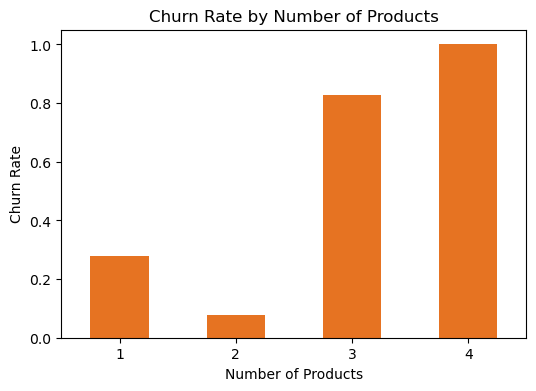

In [10]:
#churn by number of products
plt.figure(figsize=(6,4))
df.groupby('NumOfProducts')['Exited'].mean().plot(kind='bar', color='#E67322')
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

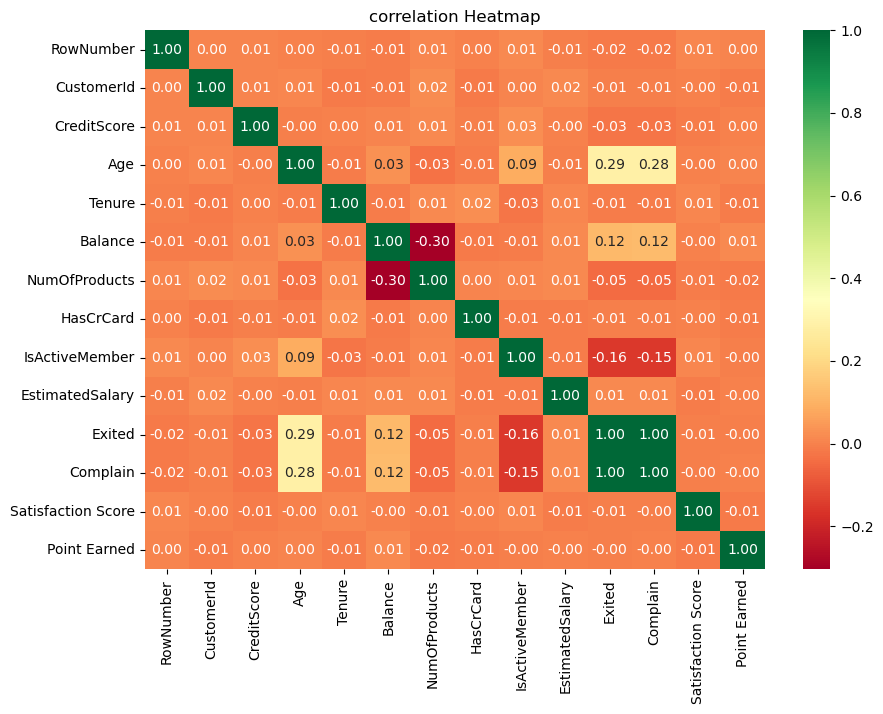

In [11]:
#correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.select_dtypes('number').corr(),
            annot=True,
            fmt='.2f',
            cmap='RdYlGn')
plt.title('correlation Heatmap')
plt.show()

In [12]:
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Complain'], axis=1)
print(df_model.shape)

(10000, 14)


In [13]:
#splitting categorical columns (the ones written object in the .info result
df_model = pd.get_dummies(df_model, columns=['Geography', 'Gender', 'Card Type'])
print(df_model.shape)
print(df_model.columns.tolist())

(10000, 20)
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Point Earned', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male', 'Card Type_DIAMOND', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']


In [14]:
x = df_model.drop('Exited', axis=1)
y = df_model['Exited']

print('Features shape:', x.shape)
print('Target shape:', y.shape)

Features shape: (10000, 19)
Target shape: (10000,)


In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set:', x_train.shape)
print('Test set:', x_test.shape)

Training set: (8000, 19)
Test set: (2000, 19)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

print('Scaling done')

Scaling done


In [17]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train_sc, y_train)

print('Before SMOTE:', y_train.value_counts().tolist())
print('After SMOTE:', y_train_res.value_counts().tolist())

Before SMOTE: [6370, 1630]
After SMOTE: [6370, 6370]


In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(x_train_res, y_train_res)

print('Model trained')

Model trained


In [19]:
from sklearn.metrics import classification_report, roc_auc_score

lr_pred = lr.predict(x_test_sc)
lr_proba = lr.predict_proba(x_test_sc)[:, 1]

print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned']))
print('AUC-ROC:', round(roc_auc_score(y_test, lr_proba), 4))

              precision    recall  f1-score   support

      Stayed       0.90      0.71      0.80      1592
     Churned       0.39      0.71      0.50       408

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

AUC-ROC: 0.781


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_res, y_train_res)

rf_pred = rf.predict(x_test_sc)
rf_proba = rf.predict_proba(x_test_sc)[:, 1]

print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned']))
print('AUC-ROC:', round(roc_auc_score(y_test, rf_proba), 4))

              precision    recall  f1-score   support

      Stayed       0.90      0.92      0.91      1592
     Churned       0.65      0.60      0.62       408

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.77      2000
weighted avg       0.85      0.85      0.85      2000

AUC-ROC: 0.8603


In [21]:
!pip install xgboost

In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(x_train_res, y_train_res)

xgb_pred = xgb.predict(x_test_sc)
xgb_proba = xgb.predict_proba(x_test_sc)[:, 1]

print(classification_report(y_test, xgb_pred, target_names=['Stayed', 'Churned']))
print('AUC-ROC:', round(roc_auc_score(y_test, xgb_proba), 4))

              precision    recall  f1-score   support

      Stayed       0.89      0.93      0.91      1592
     Churned       0.66      0.56      0.60       408

    accuracy                           0.85      2000
   macro avg       0.78      0.74      0.76      2000
weighted avg       0.84      0.85      0.85      2000

AUC-ROC: 0.8516


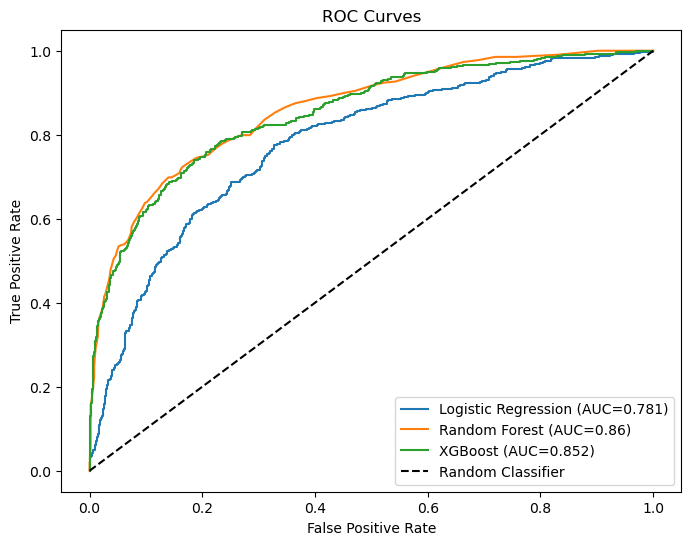

In [23]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))
for name, proba in [('Logistic Regression', lr_proba), 
                     ('Random Forest', rf_proba), 
                     ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = round(roc_auc_score(y_test, proba), 3)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc})')

plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

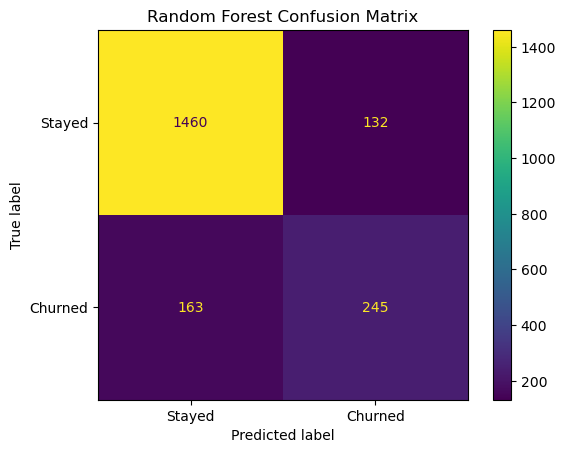

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned']).plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

In [25]:
!pip install shap

In [26]:
%matplotlib inline

In [30]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_test_sc)
print('SHAP values computed')

SHAP values computed


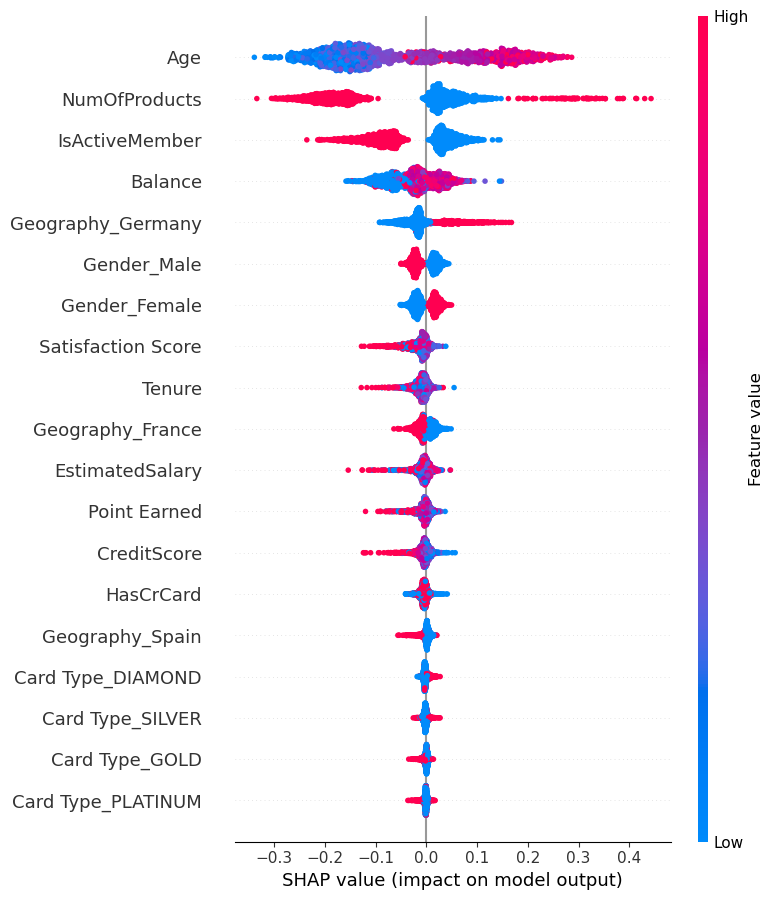

In [32]:
shap.summary_plot(shap_values[:,:,1], x_test_sc, feature_names=list(x.columns))